<a href="https://colab.research.google.com/github/nelaekasilvialumbanraja/big-data/blob/main/FlightDelay_2024_revised_ADDED_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demo1: Flight Delay Prediction

In this notebook we use the [Flight Data 2024](https://www.kaggle.com/datasets/hrishitpatil/flight-data-2024) dataset to analyze and predict flight delays in airports based on past flight records.

For this dataset, we will look at the flights in 2024.

In this notebook, we will build **a classification model to predict airline delay from historical flight data.**  



As usual, we first import some Python packages that we need:

In [ ]:
# For SQL-type queries (Spark)
from pyspark.sql import SQLContext
from pyspark.sql.types import *
from pyspark.sql import Row
from pyspark.sql.functions import udf

# Important for managing features (Spark)
from pyspark.ml.feature import OneHotEncoder, StringIndexer
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# For displaying and other related IPython tools...
from IPython.display import display
from ipywidgets import interact

# Typical Python tools
import sys
import time
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
from matplotlib import rcParams
import os.path
import kagglehub
from scipy.stats import zscore

# To show plots inline
%matplotlib inline

# Dictionary to store timing results for Spark-ML vs Local pipeline comparison
timings = {"Spark-ML": {}, "Local": {}}


In [ ]:
!pip install kagglehub pyspark scipy plotly ipywidgets -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 23.8 MB/s eta 0:00:00


### Import data
Run the following cell to download the **Flight Data 2024** dataset from Kaggle using `kagglehub`.

In [ ]:
_t_download_start = time.time()

# Download Flight Data 2024 dataset from Kaggle
path = kagglehub.dataset_download("hrishitpatil/flight-data-2024")
print("Dataset downloaded to:", path)

import glob
csv_files = glob.glob(path + "/**/*.csv", recursive=True)
csv_files = [f for f in csv_files if "sample" not in f and "dictionary" not in f]
print("CSV files found:", csv_files)
flight_csv = csv_files[0]  # use the first CSV file
print("Using file:", flight_csv)

_t_download = time.time() - _t_download_start
print(f"Download time: {_t_download:.2f} s")
# Note: dataset download is a one-time setup cost, kept separate from the
# data_loading timing used for the Local vs Spark-ML comparison.


100%|██████████| 270M/270M [00:03<00:00, 85.5MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/hrishitpatil/flight-data-2024/versions/2
CSV files found: ['/root/.cache/kagglehub/datasets/hrishitpatil/flight-data-2024/versions/2/flight_data_2024.csv']
Using file: /root/.cache/kagglehub/datasets/hrishitpatil/flight-data-2024/versions/2/flight_data_2024.csv
Download time: 39.08 s


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import SQLContext

_t0 = time.time()  # marks the start of data_loading (Spark session + textFile + parse + count)

spark = SparkSession.builder.appName("FlightDelayPrediction").getOrCreate()
sc = spark.sparkContext
sqlContext = SQLContext(sc)

textFile = sc.textFile(flight_csv)


/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:112: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


### Cleaning and exploration
In this section, we remove the header of file, get the number of records in the dataset and take a look what the data look like and the number of features we have access to.

In [ ]:
import csv, io

def split_csv_line(line):
    return next(csv.reader(io.StringIO(line)))

textFileRDD = textFile.map(split_csv_line)
header = textFileRDD.first()

textRDD = textFileRDD.filter(lambda r: r != header)


In [ ]:
num_records = textFileRDD.count()
print('Number of records', num_records)


Number of records 7079082


In [ ]:
aux_ = textFileRDD.take(2)
feature_names = aux_[0]
feature_example = aux_[1]

In [ ]:
print("Features names")
print(feature_names)


Features names
['year', 'month', 'day_of_month', 'day_of_week', 'fl_date', 'op_unique_carrier', 'op_carrier_fl_num', 'origin', 'origin_city_name', 'origin_state_nm', 'dest', 'dest_city_name', 'dest_state_nm', 'crs_dep_time', 'dep_time', 'dep_delay', 'taxi_out', 'wheels_off', 'wheels_on', 'taxi_in', 'crs_arr_time', 'arr_time', 'arr_delay', 'cancelled', 'cancellation_code', 'diverted', 'crs_elapsed_time', 'actual_elapsed_time', 'air_time', 'distance', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']


In [ ]:
print("Feature example")
print(feature_example)


Feature example
['2024', '1', '1', '1', '2024-01-01', '9E', '4814.0', 'JFK', 'New York, NY', 'New York', 'DTW', 'Detroit, MI', 'Michigan', '1252', '1247.0', '-5.0', '31.0', '1318.0', '1442.0', '7.0', '1508', '1449.0', '-19.0', '0', '', '0', '136.0', '122.0', '84.0', '509.0', '0', '0', '0', '0', '0']


In [ ]:
print("Number of features =", len(feature_example))


Number of features = 35


### Creating a SQL Dataframe from RDD

We now create a SQL DataFrame, this entity is a distributed collection of data organized into named columns. It is conceptually equivalent to a table in a relational database or a data frame in Python, but with richer optimizations under the hood. We will utilize the recently created Spark RDD and use the Spark SQL context to create the desired data frame,

We first create function that will allow to parse a record of our RDD into the desired format. As a reference we take a look at features_names and feature_example we just created above

In [ ]:
# Feature index reference (Flight Data 2024):
# 0 year, 1 month, 2 day_of_month, 3 day_of_week, 4 fl_date,
# 5 op_unique_carrier, 6 op_carrier_fl_num, 7 origin, 8 origin_city_name,
# 9 origin_state_nm, 10 dest, 11 dest_city_name, 12 dest_state_nm,
# 13 crs_dep_time, 14 dep_time, 15 dep_delay, 16 taxi_out, 17 wheels_off,
# 18 wheels_on, 19 taxi_in, 20 crs_arr_time, 21 arr_time, 22 arr_delay,
# 23 cancelled, 24 cancellation_code, 25 diverted, 26 crs_elapsed_time,
# 27 actual_elapsed_time, 28 air_time, 29 distance, 30 carrier_delay,
# 31 weather_delay, 32 nas_delay, 33 security_delay, 34 late_aircraft_delay

def parse(x):
    try:
        year = int(x[0])
        month = int(x[1])
        day = int(x[2])
        day_of_week = int(x[3])

        y = Row(Year=year,
                Month=month,
                DayofMonth=day,
                DayOfWeek=day_of_week,
                DepTime=int(float(x[14])) if x[14].strip() else 0,        # dep_time
                CRSDepTime=int(float(x[13])) if x[13].strip() else 0,     # crs_dep_time
                ArrTime=int(float(x[21])) if x[21].strip() else 0,        # arr_time
                CRSArrTime=int(float(x[20])) if x[20].strip() else 0,     # crs_arr_time
                UniqueCarrier=x[5],                                       # op_unique_carrier
                DepDelay=int(float(x[15])) if x[15].strip() else 0,       # dep_delay
                Origin=x[7],                                              # origin
                Dest=x[10],                                               # dest
                Distance=int(float(x[29])) if x[29].strip() else 0)       # distance
    except Exception as e:
        # print(f"Error parsing row: {x} - {e}") # Uncomment for debugging if needed
        y = None
    return y


We now apply the previous function to our RDD and use it to create the SQL dataframe.

In [ ]:
rowRDD = textRDD.map(lambda x: parse(x)).filter(lambda x: x != None)
df = sqlContext.createDataFrame(rowRDD)
df.cache()
_n = df.count()  # force evaluation to get a fair timing for data loading

timings["Spark-ML"]["data_loading"] = time.time() - _t0
print(f"[Spark-ML] Data loading time: {timings['Spark-ML']['data_loading']:.2f} s ({_n} rows)")

_t_pre0 = time.time()


[Spark-ML] Data loading time: 293.74 s (7079081 rows)


We add a new column to our data frame, **DepDelayed**, a binary variable:
- **True**, for flights that have > 15 minutes of delay
- **False**, for flights that have <= 15 minutes of delay

We will later use **Depdelayed** as the target/label column in the classification process.

In [ ]:
df = df.withColumn('DepDelayed', df['DepDelay']>15)

In [ ]:
df.take(5)

[Row(Year=2024, Month=1, DayofMonth=1, DayOfWeek=1, DepTime=1247, CRSDepTime=1252, ArrTime=1449, CRSArrTime=1508, UniqueCarrier='9E', DepDelay=-5, Origin='JFK', Dest='DTW', Distance=509, DepDelayed=False),
 Row(Year=2024, Month=1, DayofMonth=1, DayOfWeek=1, DepTime=1001, CRSDepTime=1015, ArrTime=1255, CRSArrTime=1325, UniqueCarrier='9E', DepDelay=-14, Origin='MSP', Dest='CLE', Distance=622, DepDelayed=False),
 Row(Year=2024, Month=1, DayofMonth=1, DayOfWeek=1, DepTime=1411, CRSDepTime=1415, ArrTime=1541, CRSArrTime=1601, UniqueCarrier='9E', DepDelay=-4, Origin='JFK', Dest='RIC', Distance=288, DepDelayed=False),
 Row(Year=2024, Month=1, DayofMonth=1, DayOfWeek=1, DepTime=1643, CRSDepTime=1650, ArrTime=1759, CRSArrTime=1841, UniqueCarrier='9E', DepDelay=-7, Origin='RIC', Dest='JFK', Distance=288, DepDelayed=False),
 Row(Year=2024, Month=1, DayofMonth=1, DayOfWeek=1, DepTime=1010, CRSDepTime=1015, ArrTime=1020, CRSArrTime=1034, UniqueCarrier='9E', DepDelay=-5, Origin='DTW', Dest='MKE', Di

We also add a new column, __Hour__, to determine the hour of flight (0 to 24). For this purpouse we first define the following auxiliary function. Once created we will register it as a **user defined function (UDF).** This is useful when adding functions into the SparkSQL language.

In [ ]:
# Function to obtain hour of day
def get_hour(x):
    h = int(str(int(x)).zfill(4)[:2])
    return h

# Register our function as a UDF
f = udf(get_hour, IntegerType())

We use the CRSDepTime field and the previously UDF to add the Hour column to our SQL dataframe. Recall that CRSDepTime has the following structure:
* CRSDepTime: scheduled departure time (local, hhmm)

In [ ]:
#CRSDepTime: scheduled departure time (local, hhmm)
df = df.withColumn('Hour', f(df.CRSDepTime))
df.createOrReplaceTempView("airlineDF")

timings["Spark-ML"]["data_preprocessing_initial"] = time.time() - _t_pre0
print(f"[Spark-ML] Initial preprocessing time: {timings['Spark-ML']['data_preprocessing_initial']:.2f} s")


[Spark-ML] Initial preprocessing time: 1.29 s


In [ ]:
df.take(2)

[Row(Year=2024, Month=1, DayofMonth=1, DayOfWeek=1, DepTime=1247, CRSDepTime=1252, ArrTime=1449, CRSArrTime=1508, UniqueCarrier='9E', DepDelay=-5, Origin='JFK', Dest='DTW', Distance=509, DepDelayed=False, Hour=12),
 Row(Year=2024, Month=1, DayofMonth=1, DayOfWeek=1, DepTime=1001, CRSDepTime=1015, ArrTime=1255, CRSArrTime=1325, UniqueCarrier='9E', DepDelay=-14, Origin='MSP', Dest='CLE', Distance=622, DepDelayed=False, Hour=10)]

### Skema Data dan Statistik Deskriptif

Sebelum melanjutkan ke tahap eksplorasi dan modeling, kita periksa **skema** (tipe data
setiap kolom) serta **statistik deskriptif** (count, mean, stddev, min, max) dari
DataFrame Spark yang telah dibuat. Langkah ini umum dilakukan pada tahap *data
understanding* dalam pipeline machine learning (lihat referensi `pyspark_ml.ipynb`,
bagian *Eksplorasi Data*), dan membantu mendeteksi kolom dengan nilai yang tidak wajar
(misalnya nilai negatif pada `Distance` atau `Hour` di luar rentang 0–23) sebelum masuk
ke tahap *feature engineering*.

Kita juga melakukan pengecekan **nilai kosong (missing values / null)** pada setiap
kolom, sebuah langkah standar pada *data quality assessment* (lihat referensi
`pyspark_parquet.ipynb`, bagian *Check for missing values*).

In [ ]:
# ── Skema DataFrame (referensi: pyspark_ml.ipynb -> printSchema) ────────────
df.printSchema()


root
 |-- Year: long (nullable = true)
 |-- Month: long (nullable = true)
 |-- DayofMonth: long (nullable = true)
 |-- DayOfWeek: long (nullable = true)
 |-- DepTime: long (nullable = true)
 |-- CRSDepTime: long (nullable = true)
 |-- ArrTime: long (nullable = true)
 |-- CRSArrTime: long (nullable = true)
 |-- UniqueCarrier: string (nullable = true)
 |-- DepDelay: long (nullable = true)
 |-- Origin: string (nullable = true)
 |-- Dest: string (nullable = true)
 |-- Distance: long (nullable = true)
 |-- DepDelayed: boolean (nullable = true)
 |-- Hour: integer (nullable = true)



In [ ]:
# ── Statistik deskriptif (referensi: pyspark_ml.ipynb -> describe/summary) ──
df.select("Year", "Month", "DayofMonth", "DayOfWeek", "DepDelay",
          "Distance", "Hour").summary("count", "mean", "stddev", "min", "max").show()


+-------+-------+-----------------+------------------+-----------------+------------------+-----------------+------------------+
|summary|   Year|            Month|        DayofMonth|        DayOfWeek|          DepDelay|         Distance|              Hour|
+-------+-------+-----------------+------------------+-----------------+------------------+-----------------+------------------+
|  count|7079081|          7079081|           7079081|          7079081|           7079081|          7079081|           7079081|
|   mean| 2024.0|6.584868290107148|15.784451258574382|3.981944972800848|12.510593112298052|833.9061503887299|13.003835808631091|
| stddev|    0.0|3.396806482581405| 8.786432524408651|2.012279347468831| 55.70933135621688|596.2535939770976|  4.90054588744749|
|    min|   2024|                1|                 1|                1|               -96|               11|                 0|
|    max|   2024|               12|                31|                7|              3777|      

In [ ]:
# ── Cek missing values per kolom (referensi: pyspark_parquet.ipynb) ─────────
from pyspark.sql.functions import col as _col, count as _count, when as _when

df.select([
    _count(_when(_col(c).isNull(), c)).alias(c) for c in df.columns
]).show()


+----+-----+----------+---------+-------+----------+-------+----------+-------------+--------+------+----+--------+----------+----+
|Year|Month|DayofMonth|DayOfWeek|DepTime|CRSDepTime|ArrTime|CRSArrTime|UniqueCarrier|DepDelay|Origin|Dest|Distance|DepDelayed|Hour|
+----+-----+----------+---------+-------+----------+-------+----------+-------------+--------+------+----+--------+----------+----+
|   0|    0|         0|        0|      0|         0|      0|         0|            0|       0|     0|   0|       0|         0|   0|
+----+-----+----------+---------+-------+----------+-------+----------+-------------+--------+------+----+--------+----------+----+



## Exploration
Let's do some exploration of this dataset.  Let's start by taking a look at airpors that have the most delays.

In [ ]:
# We select, from our SQL context the columns of interest...
groupedDelay = sqlContext.sql("SELECT Origin, count(*) conFlight,avg(DepDelay) delay \
                                FROM airlineDF \
                                GROUP BY Origin")

# ... and turn it into a Padas data frame
df_origin = groupedDelay.toPandas()

In [ ]:
df_origin.shape

(348, 3)

In [ ]:
df_origin.head(10)

,Origin,conFlight,delay
0,BGM,367,12.648501
1,PSE,945,8.081481
2,INL,653,13.698315
3,MSY,50173,13.975385
4,PPG,125,19.992000
5,GEG,17527,6.545330
6,BUR,30636,9.468175
7,SNA,43519,10.484294
8,GRB,4203,12.657863
9,GTF,2436,6.656814


__Notice:__ To map each Airport to corresponding _Long_ and _Lat_, run the following cell to download the needed dataset.

In [ ]:
# Auxiliary dataset for airport coordinates (lat/lng), since the
# Flight Data 2024 dataset (Kaggle: hrishitpatil/flight-data-2024) does NOT
# contain geographic coordinates. We use the OpenFlights airports database
# as an auxiliary reference table (IATA code -> lat/lng), commonly used as
# a geospatial enrichment source in flight-delay studies.
airports_url = "https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat"

airport_cols = ["AirportID", "Name", "City", "Country", "IATA", "ICAO",
                "lat", "lng", "Altitude", "Timezone", "DST", "Tz",
                "Type", "Source"]

df_aux = pd.read_csv(airports_url, header=None, names=airport_cols)
df_aux = df_aux[["IATA", "lat", "lng"]].dropna(subset=["IATA"])
df_aux = df_aux[df_aux["IATA"] != "\\N"]

print("Auxiliary airport coordinate dataset shape:", df_aux.shape)
df_aux.head()


Auxiliary airport coordinate dataset shape: (6072, 3)


,IATA,lat,lng
0,GKA,-6.081690,145.391998
1,MAG,-5.207080,145.789001
2,HGU,-5.826790,144.296005
3,LAE,-6.569803,146.725977
4,POM,-9.443380,147.220001


In [ ]:
df_aux.head()
df_aux.dtypes


,0
IATA,object
lat,float64
lng,float64


In [ ]:
df_airports = pd.merge(df_origin, df_aux, left_on='Origin', right_on='IATA')


In [ ]:
df_airports.shape

(346, 6)

In [ ]:
df_airports.head()

,Origin,conFlight,delay,IATA,lat,lng
0,BGM,367,12.648501,BGM,42.208698,-75.979797
1,PSE,945,8.081481,PSE,18.008301,-66.563004
2,INL,653,13.698315,INL,48.566200,-93.403099
3,MSY,50173,13.975385,MSY,29.993401,-90.258003
4,PPG,125,19.992000,PPG,-14.331000,-170.710007


The following two functions are defined to support the design of the map that will show airports as well as routs of the data of interest. Recall that the sigmoid funcion maps the set of real numbers to the [-1,1] interval. Zscore provides the score of a set of data according to the normal distribution.

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def Zscore(x):
    return (x - np.average(x)) / np.std(x)


The following cell provides the necessary ingrediants to plot the map of interest.

In [ ]:
import plotly.express as px

# Normalize delay for color scale using z-score + sigmoid (as in original analysis)
df_airports = df_airports.copy()
df_airports['delay_score'] = sigmoid(zscore(df_airports['delay']))

fig = px.scatter_geo(
    df_airports,
    lat='lat', lon='lng',
    size='conFlight',
    color='delay_score',
    color_continuous_scale='Hot_r',
    hover_name='Origin',
    scope='usa',
    title='Airport Traffic (size) and Average Departure Delay (color)'
)
fig.update_layout(height=600)
fig.show()

print("Each marker is an airport.")
print("Size of markers: Airport Traffic (larger means higher number of flights in year)")
print("Color of markers: Average Flight Delay (Redder means longer delays)")


Each marker is an airport.
Size of markers: Airport Traffic (larger means higher number of flights in year)
Color of markers: Average Flight Delay (Redder means longer delays)


### Explorating route delays

We now will explore routes that are typically the most delayed.

In [ ]:
# We select, from out SQLContext, fields that are of our interest to get
# the routes that are the most delayed...
grp_rout_Delay = sqlContext.sql("SELECT Origin, Dest, count(*) traffic,avg(Distance) avgDist,\
                                    avg(DepDelay) avgDelay\
                                FROM airlineDF \
                                GROUP BY Origin,Dest")
# ... and turn it into a pandas dataframe
rout_Delay = grp_rout_Delay.toPandas()

In [ ]:
rout_Delay.head()

,Origin,Dest,traffic,avgDist,avgDelay
0,PHL,MCO,5574,861.0,19.375135
1,PBI,DCA,1668,857.0,17.455635
2,SNA,PHX,4350,338.0,11.808276
3,ORD,PDX,2259,1739.0,14.688800
4,BQN,MCO,917,1129.0,17.124318


In [ ]:
df_aux.head()


,IATA,lat,lng
0,GKA,-6.081690,145.391998
1,MAG,-5.207080,145.789001
2,HGU,-5.826790,144.296005
3,LAE,-6.569803,146.725977
4,POM,-9.443380,147.220001


In [ ]:
# Merge route-delay dataframe with airport coordinates (Origin side)
df_airport_rout1 = pd.merge(rout_Delay, df_aux, left_on='Origin', right_on='IATA')


In [ ]:
df_airport_rout1.head()

,Origin,Dest,traffic,avgDist,avgDelay,IATA,lat,lng
0,PHL,MCO,5574,861.0,19.375135,PHL,39.871899,-75.241096
1,PBI,DCA,1668,857.0,17.455635,PBI,26.683201,-80.095596
2,SNA,PHX,4350,338.0,11.808276,SNA,33.675701,-117.867996
3,ORD,PDX,2259,1739.0,14.688800,ORD,41.978600,-87.904800
4,BQN,MCO,917,1129.0,17.124318,BQN,18.494900,-67.129402


In [ ]:
df_airport_rout1.head()

,Origin,Dest,traffic,avgDist,avgDelay,IATA,lat,lng
0,PHL,MCO,5574,861.0,19.375135,PHL,39.871899,-75.241096
1,PBI,DCA,1668,857.0,17.455635,PBI,26.683201,-80.095596
2,SNA,PHX,4350,338.0,11.808276,SNA,33.675701,-117.867996
3,ORD,PDX,2259,1739.0,14.688800,ORD,41.978600,-87.904800
4,BQN,MCO,917,1129.0,17.124318,BQN,18.494900,-67.129402


In [ ]:
df_aux.head()


,IATA,lat,lng
0,GKA,-6.081690,145.391998
1,MAG,-5.207080,145.789001
2,HGU,-5.826790,144.296005
3,LAE,-6.569803,146.725977
4,POM,-9.443380,147.220001


In [ ]:
# Merge again to get coordinates for the Destination side
df_airport_rout2 = pd.merge(df_airport_rout1, df_aux, left_on='Dest', right_on='IATA',
                             suffixes=('_x', '_y'))


In [ ]:
df_airport_rout2.head()

,Origin,Dest,traffic,avgDist,avgDelay,IATA_x,lat_x,lng_x,IATA_y,lat_y,lng_y
0,PHL,MCO,5574,861.0,19.375135,PHL,39.871899,-75.241096,MCO,28.429399,-81.308998
1,PBI,DCA,1668,857.0,17.455635,PBI,26.683201,-80.095596,DCA,38.852100,-77.037697
2,SNA,PHX,4350,338.0,11.808276,SNA,33.675701,-117.867996,PHX,33.434299,-112.012001
3,ORD,PDX,2259,1739.0,14.688800,ORD,41.978600,-87.904800,PDX,45.588699,-122.598000
4,BQN,MCO,917,1129.0,17.124318,BQN,18.494900,-67.129402,MCO,28.429399,-81.308998


In [ ]:
df_airport_rout = df_airport_rout2[["Origin", "lat_x", "lng_x", "Dest", "lat_y", "lng_y",
                                     "avgDelay", "traffic"]]


In [ ]:
df_airport_rout.head()

,Origin,lat_x,lng_x,Dest,lat_y,lng_y,avgDelay,traffic
0,PHL,39.871899,-75.241096,MCO,28.429399,-81.308998,19.375135,5574
1,PBI,26.683201,-80.095596,DCA,38.852100,-77.037697,17.455635,1668
2,SNA,33.675701,-117.867996,PHX,33.434299,-112.012001,11.808276,4350
3,ORD,41.978600,-87.904800,PDX,45.588699,-122.598000,14.688800,2259
4,BQN,18.494900,-67.129402,MCO,28.429399,-81.308998,17.124318,917


We now generate a similar map as before but this time showing routes

In [ ]:
import plotly.graph_objects as go

df_airport_rout['delay_score'] = sigmoid(zscore(df_airport_rout['avgDelay']))

fig = go.Figure()

# Draw routes as lines
for _, row in df_airport_rout.iterrows():
    color_idx = row['delay_score']
    fig.add_trace(go.Scattergeo(
        lon=[row['lng_x'], row['lng_y']],
        lat=[row['lat_x'], row['lat_y']],
        mode='lines',
        line=dict(width=1, color=f'rgba(255,{int(255*(1-color_idx))},0,0.15)'),
        showlegend=False
    ))

# Overlay airport markers
fig.add_trace(go.Scattergeo(
    lon=df_airports['lng'], lat=df_airports['lat'],
    mode='markers',
    marker=dict(size=6, color=df_airports['delay_score'],
                 colorscale='Hot_r', showscale=True),
    text=df_airports['Origin'],
    name='Airports'
))

fig.update_layout(
    title='Flight Routes Colored by Average Departure Delay',
    geo=dict(scope='usa'),
    height=600
)
fig.show()

print("Each line represents a route from the Origin to Destination airport.")
print("The redder line, the higher probability of delay.")


/tmp/ipykernel_9009/1659689272.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Each line represents a route from the Origin to Destination airport.
The redder line, the higher probability of delay.


### Exploring airport origin delay per month

We set the airport code name we want to explore, say **JFK**

In [ ]:
Origin_Airport="JFK"

In [ ]:
df_ORG = sqlContext.sql("SELECT * from airlineDF WHERE Origin='" + Origin_Airport + "'")
df_ORG.createOrReplaceTempView("df_ORG")
df_ORG.select('ArrTime', 'CRSArrTime', 'CRSDepTime',
               'DayOfWeek', 'DayofMonth', 'DepDelay', 'DepTime', 'Dest').show(2)


+-------+----------+----------+---------+----------+--------+-------+----+
|ArrTime|CRSArrTime|CRSDepTime|DayOfWeek|DayofMonth|DepDelay|DepTime|Dest|
+-------+----------+----------+---------+----------+--------+-------+----+
|   1449|      1508|      1252|        1|         1|      -5|   1247| DTW|
|   1541|      1601|      1415|        1|         1|      -4|   1411| RIC|
+-------+----------+----------+---------+----------+--------+-------+----+
only showing top 2 rows


Let's look at the number of flights originating from this airport:

In [ ]:
print("Total flights from this airport: " + str(df_ORG.count()))


Total flights from this airport: 123348


We now group flights by month to see how delayed flights are distributed by month:

In [ ]:
grp_carr = sqlContext.sql("SELECT UniqueCarrier, Month, avg(DepDelay) avgDelay from df_ORG \
                            WHERE DepDelayed=true \
                            GROUP BY UniqueCarrier, Month")
s = grp_carr.toPandas()


In [ ]:
s.head()

,UniqueCarrier,Month,avgDelay
0,DL,1,68.472554
1,AS,1,79.718750
2,B6,1,70.619632
3,AA,1,81.856354
4,9E,1,93.232365


In [ ]:
# Use the top carriers actually present for this airport (instead of hardcoded AA/UA/US,
# since carrier codes operating from a given airport vary in the 2024 dataset)
top_carriers = s.groupby('UniqueCarrier')['avgDelay'].count().sort_values(ascending=False).head(3).index.tolist()
ps = s.pivot(index='Month', columns='UniqueCarrier', values='avgDelay')[top_carriers]


In [ ]:
ps.head()

UniqueCarrier,9E,AA,AS
Month,,,
1,93.232365,81.856354,79.718750
2,77.814815,92.153846,44.444444
3,68.104167,71.695906,64.901961
4,69.729358,93.832298,73.258065
5,90.687500,99.829493,88.947368


Text(0.5, 1.0, 'Carrier delay in each month')

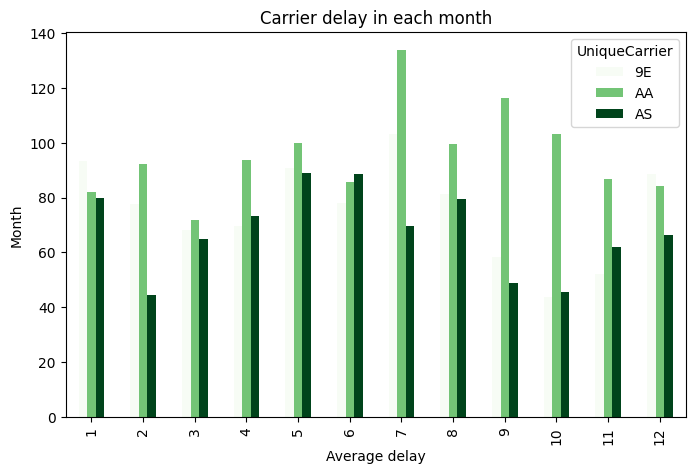

In [ ]:
rcParams['figure.figsize'] = (8,5)
ps.plot(kind='bar', colormap='Greens');
plt.xlabel('Average delay')
plt.ylabel('Month')
plt.title('Carrier delay in each month')

### Exploring airport origin delay per day/hour

In [ ]:
hour_grouped = df_ORG.filter(df_ORG['DepDelayed']).select('DayOfWeek', 'Hour', 'DepDelay') \
                     .groupby('DayOfWeek', 'Hour').mean('DepDelay')


In [ ]:
hour_grouped.take(3)

[Row(DayOfWeek=1, Hour=12, avg(DepDelay)=67.05555555555556),
 Row(DayOfWeek=6, Hour=13, avg(DepDelay)=70.18324607329843),
 Row(DayOfWeek=1, Hour=17, avg(DepDelay)=81.7919708029197)]

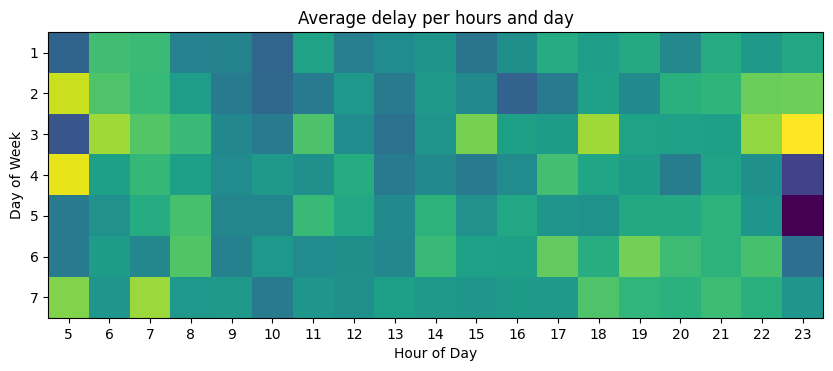

In [ ]:
rcParams['figure.figsize'] = (10,5)
dh = hour_grouped.toPandas()
c = dh.pivot(index='DayOfWeek', columns='Hour', values='avg(DepDelay)')
X = c.columns.values
Y = c.index.values
Z = c.values
plt.xticks(range(0, len(X)), X)
plt.yticks(range(0, len(Y)), Y)
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.title('Average delay per hours and day')
plt.imshow(Z)

A clear pattern here: flights tend to be delayed in these situations:  
- Later in the day: possibly because delays tend to pile up as the day progresses and the problem tends to compound later in the day.  
- Mornings in first day of week possibly because of more business meetings

## Modeling: Logistic Regression
In this section, we will build a supervised learning model to predict flight delays for flights leaving our selected airport.


### Preprocessing: Feature selection
In the next two cell we select the features that we need to create the model.

In [ ]:
_t_mpre0 = time.time()

df_model=df_ORG
# stringIndexer1 = StringIndexer(inputCol="Origin", outputCol="originIndex")
# model_stringIndexer = stringIndexer1.fit(df_model)
# indexedOrigin = model_stringIndexer.transform(df_model)
# encoder1 = OneHotEncoder(dropLast=False, inputCol="originIndex", outputCol="originVec")
# df_model = encoder1.transform(indexedOrigin)


In [ ]:
stringIndexer2 = StringIndexer(inputCol="Dest", outputCol="destIndex")
model_stringIndexer = stringIndexer2.fit(df_model)
indexedDest = model_stringIndexer.transform(df_model)
# Fix: First fit the OneHotEncoder to create a model, then use the model to transform.
# This makes the 'encoder2' variable hold the fitted model for subsequent transformations.
encoder2 = OneHotEncoder(dropLast=False, inputCol="destIndex", outputCol="destVec").fit(indexedDest)
df_model = encoder2.transform(indexedDest)

We use __labeled point__ to make local vectors associated with a label/response. In MLlib, labeled points are used in supervised learning algorithms and they are stored as doubles. For binary classification, a label should be either 0 (negative) or 1 (positive).

In [ ]:
assembler = VectorAssembler(
    inputCols=['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'Hour', 'Distance', 'destVec'],
    outputCol="features")
output = assembler.transform(df_model)

# Label column: cast boolean DepDelayed to integer label
output = output.withColumn("label", output['DepDelayed'].cast("integer"))

model_df = output.select("features", "label")
model_df.cache()
_n_model = model_df.count()

timings["Spark-ML"]["data_preprocessing_modeling"] = time.time() - _t_mpre0
print(f"[Spark-ML] Modeling-stage preprocessing time: {timings['Spark-ML']['data_preprocessing_modeling']:.2f} s ({_n_model} rows)")

# Total preprocessing = initial + modeling-stage
timings["Spark-ML"]["data_preprocessing"] = (
    timings["Spark-ML"]["data_preprocessing_initial"]
    + timings["Spark-ML"]["data_preprocessing_modeling"]
)


[Spark-ML] Modeling-stage preprocessing time: 77.86 s (123348 rows)


### Preprocessing: Feature Scaling dengan `StandardScaler`

Sebagian fitur numerik kita (`Year`, `Month`, `DayofMonth`, `DayOfWeek`, `Hour`,
`Distance`) memiliki skala yang berbeda-beda. Walaupun **Logistic Regression** di
PySpark MLlib relatif robust terhadap perbedaan skala (terutama dengan regularisasi
default), praktik standar pada pipeline ML — seperti yang ditunjukkan pada referensi
`pyspark_ml.ipynb` (bagian *Spark MLlib* -> `StandardScaler`) — adalah melakukan
**standardisasi** (zero mean, unit variance) sebelum melatih model. Hal ini juga
mempersiapkan pipeline agar mudah dipertukarkan dengan algoritma lain yang sensitif
terhadap skala (misalnya SVM atau model berbasis jarak/regularisasi L2 yang kuat).

Kita tambahkan kolom `features_scaled` sebagai alternatif representasi fitur,
sekaligus mencatatnya sebagai bagian dari tahap *data_preprocessing*.

In [ ]:
# ── StandardScaler pada feature vector (referensi: pyspark_ml.ipynb) ────────
from pyspark.ml.feature import StandardScaler

_t_scale0 = time.time()

standardScaler = StandardScaler(inputCol="features", outputCol="features_scaled",
                                 withMean=True, withStd=True)
scaler_model = standardScaler.fit(model_df)
model_df = scaler_model.transform(model_df)
model_df.cache()
_n_scaled = model_df.count()

_t_scale = time.time() - _t_scale0
# Tambahkan waktu scaling ke total preprocessing
timings["Spark-ML"]["data_preprocessing"] += _t_scale
print(f"[Spark-ML] Feature scaling time: {_t_scale:.4f} s ({_n_scaled} rows)")

model_df.select("features", "features_scaled", "label").show(5, truncate=False)


[Spark-ML] Feature scaling time: 6.4398 s (123348 rows)
+----------------------------------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### Preprocessing: Spliting dataset into train and test dtasets

In [ ]:
trainDF, testDF = model_df.randomSplit([0.7, 0.3], seed=42)
print(trainDF.count(), testDF.count())


86347 37001


### Build the model

In [ ]:
_t0 = time.time()

lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=50)
model = lr.fit(trainDF)

timings["Spark-ML"]["model_training"] = time.time() - _t0
print(f"[Spark-ML] Model training time: {timings['Spark-ML']['model_training']:.2f} s")


[Spark-ML] Model training time: 35.74 s


## Model Evaluation

In [ ]:
# Evaluating the model on testing data
_t0 = time.time()

predictions = model.transform(testDF)
_n_pred = predictions.count()  # force evaluation

timings["Spark-ML"]["inference"] = time.time() - _t0
print(f"[Spark-ML] Inference time: {timings['Spark-ML']['inference']:.2f} s ({_n_pred} rows)")

predictions.select("label", "prediction").show(5)


[Spark-ML] Inference time: 1.85 s (37001 rows)
+-----+----------+
|label|prediction|
+-----+----------+
|    0|       0.0|
|    0|       0.0|
|    0|       0.0|
|    1|       0.0|
|    0|       0.0|
+-----+----------+
only showing top 5 rows


In [ ]:
from pyspark.sql import functions as F

conf_df = predictions.groupBy("label", "prediction").count().toPandas()

def conf_label(r):
    if r['label'] == 1 and r['prediction'] == 1:
        return 'TP'
    if r['label'] == 0 and r['prediction'] == 0:
        return 'TN'
    if r['label'] == 1 and r['prediction'] == 0:
        return 'FN'
    if r['label'] == 0 and r['prediction'] == 1:
        return 'FP'

conf_df['type'] = conf_df.apply(conf_label, axis=1)
conf_df

acc = conf_df.set_index('type')['count'].to_dict()
TP = acc.get('TP', 0)
TN = acc.get('TN', 0)
FP = acc.get('FP', 0)
FN = acc.get('FN', 0)
Accuracy = (TP + TN) / (TP + TN + FP + FN)
print("Accuracy = %1.2f %%" % (Accuracy * 100))

# Additional metric: AUC (common metric for binary classification, robust to class imbalance)
evaluator = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
auc_spark = evaluator.evaluate(predictions)
print(f"[Spark-ML] AUC: {auc_spark:.4f}")


Accuracy = 80.84 %
[Spark-ML] AUC: 0.6480


In [ ]:
print("Model Accuracy for JFK: %1.2f %%" % (Accuracy * 100))

# Store metrics for final comparison report
metrics = {"Spark-ML": {"accuracy": Accuracy, "auc": auc_spark},
           "Local": {}}


Model Accuracy for JFK: 80.84 %


---
## Metrik Klasifikasi Spark-ML: Lengkap

Bagian ini mengukur **Precision, Recall, F1-Score, dan AUC** untuk pipeline Spark-ML,
sesuai ketentuan tugas (metrik klasifikasi + waktu komputasi tiap tahapan).

- **Accuracy** : proporsi prediksi benar dari seluruh sampel  
- **Precision** : dari semua yang diprediksi *delayed*, berapa yang benar-benar delayed  
- **Recall**    : dari semua yang benar-benar *delayed*, berapa yang berhasil terdeteksi  
- **F1-Score**  : harmonic mean antara Precision dan Recall  
- **AUC-ROC**   : area di bawah kurva ROC; semakin mendekati 1.0 semakin baik


In [ ]:
# ── Spark-ML: Precision, Recall, F1-Score ──────────────────────────────────
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

mc_eval = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction"
)

precision_spark = mc_eval.evaluate(predictions, {mc_eval.metricName: "weightedPrecision"})
recall_spark    = mc_eval.evaluate(predictions, {mc_eval.metricName: "weightedRecall"})
f1_spark        = mc_eval.evaluate(predictions, {mc_eval.metricName: "f1"})

print(f"[Spark-ML] Accuracy  : {Accuracy*100:.2f} %")
print(f"[Spark-ML] Precision : {precision_spark:.4f}")
print(f"[Spark-ML] Recall    : {recall_spark:.4f}")
print(f"[Spark-ML] F1-Score  : {f1_spark:.4f}")
print(f"[Spark-ML] AUC-ROC   : {auc_spark:.4f}")

# Simpan ke dict metrics untuk chart perbandingan akhir
metrics["Spark-ML"].update({
    "precision": precision_spark,
    "recall":    recall_spark,
    "f1":        f1_spark,
    "auc":       auc_spark,
})


[Spark-ML] Accuracy  : 80.84 %
[Spark-ML] Precision : 0.7414
[Spark-ML] Recall    : 0.8084
[Spark-ML] F1-Score  : 0.7245
[Spark-ML] AUC-ROC   : 0.6480


### Confusion Matrix (Spark-ML)

Confusion matrix menunjukkan distribusi prediksi model terhadap label sebenarnya:
- **TP** (True Positive) : benar-benar delayed, diprediksi delayed  
- **TN** (True Negative) : tidak delayed, diprediksi tidak delayed  
- **FP** (False Positive): tidak delayed, diprediksi delayed (*false alarm*)  
- **FN** (False Negative): delayed, diprediksi tidak delayed (*missed*)


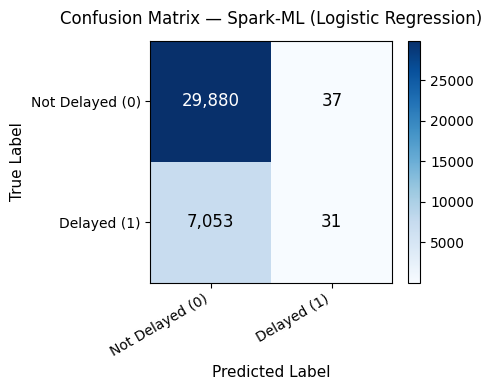

TN=29,880  FP=37  FN=7,053  TP=31


In [ ]:
# ── Confusion Matrix Heatmap ─────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

cm_dict = {"TP": TP, "TN": TN, "FP": FP, "FN": FN}
cm_matrix = np.array([[TN, FP],
                       [FN, TP]])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_matrix, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)

classes = ['Not Delayed (0)', 'Delayed (1)']
tick_marks = np.arange(len(classes))
ax.set_xticks(tick_marks); ax.set_xticklabels(classes, rotation=30, ha='right')
ax.set_yticks(tick_marks); ax.set_yticklabels(classes)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title('Confusion Matrix — Spark-ML (Logistic Regression)', fontsize=12, pad=12)

thresh = cm_matrix.max() / 2
for i in range(2):
    for j in range(2):
        label = f"{cm_matrix[i,j]:,}"
        ax.text(j, i, label, ha="center", va="center",
                color="white" if cm_matrix[i,j] > thresh else "black", fontsize=12)

plt.tight_layout()
plt.savefig('/tmp/confusion_matrix_spark.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"TN={TN:,}  FP={FP:,}  FN={FN:,}  TP={TP:,}")


### ROC Curve (Spark-ML)

Kurva ROC memplot *True Positive Rate* (Recall/Sensitivity) terhadap *False Positive Rate*
pada berbagai threshold. Area di bawah kurva (AUC) yang mendekati **1.0** menandakan
model yang sangat baik; **0.5** setara dengan random guess.


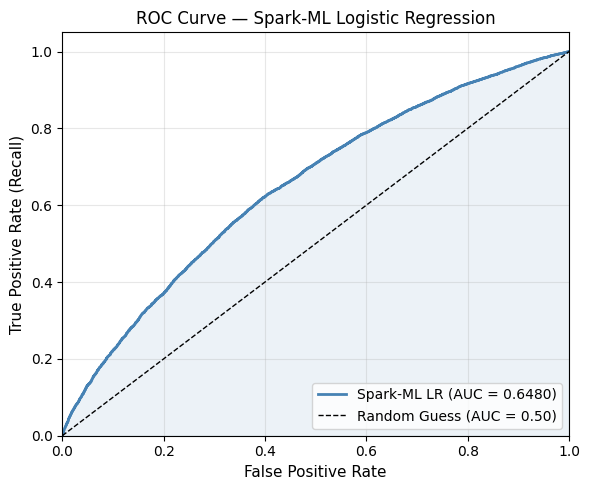

[Spark-ML] AUC (sklearn verify): 0.6480


In [ ]:
# ── ROC Curve — Spark-ML ──────────────────────────────────────────────────────
# Ekstrak probabilitas kelas 1 dari kolom 'probability' (DenseVector)
from pyspark.sql.functions import col as F_col

prob_df = predictions.select(
    "label",
    F_col("probability")
).toPandas()

# probability column adalah DenseVector -> ambil elemen ke-1 (P(delayed))
prob_df["prob_delayed"] = prob_df["probability"].apply(lambda v: float(v[1]))

from sklearn.metrics import roc_curve, auc as sk_auc

fpr, tpr, thresholds = roc_curve(prob_df["label"], prob_df["prob_delayed"])
roc_auc_val = sk_auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'Spark-ML LR (AUC = {roc_auc_val:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guess (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('ROC Curve — Spark-ML Logistic Regression', fontsize=12)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/tmp/roc_curve_spark.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"[Spark-ML] AUC (sklearn verify): {roc_auc_val:.4f}")


### Precision-Recall Curve dan `areaUnderPR` (Spark-ML)

Selain **ROC-AUC**, `BinaryClassificationEvaluator` pada PySpark MLlib juga
menyediakan metrik **`areaUnderPR`** (luas area di bawah kurva Precision-Recall).
Metrik ini sering lebih informatif dibandingkan ROC-AUC ketika kelas target tidak
seimbang (*class imbalance*) — kondisi yang umum terjadi pada kasus prediksi
keterlambatan penerbangan, di mana proporsi flight yang *delayed* biasanya lebih
kecil dibandingkan yang *on-time*.

[Spark-ML] Area Under Precision-Recall Curve (AUPRC): 0.2976


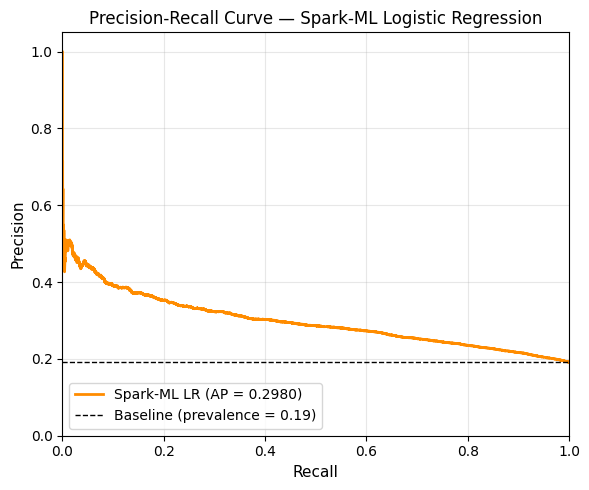

In [ ]:
# ── Precision-Recall Curve & areaUnderPR — Spark-ML ──────────────────────────
evaluator_pr = BinaryClassificationEvaluator(
    labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderPR"
)
auprc_spark = evaluator_pr.evaluate(predictions)
print(f"[Spark-ML] Area Under Precision-Recall Curve (AUPRC): {auprc_spark:.4f}")

from sklearn.metrics import precision_recall_curve, average_precision_score

prec_curve, rec_curve, _ = precision_recall_curve(prob_df["label"], prob_df["prob_delayed"])
ap_score = average_precision_score(prob_df["label"], prob_df["prob_delayed"])

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(rec_curve, prec_curve, color='darkorange', lw=2,
        label=f'Spark-ML LR (AP = {ap_score:.4f})')
baseline = prob_df["label"].mean()
ax.axhline(baseline, color='k', ls='--', lw=1, label=f'Baseline (prevalence = {baseline:.2f})')
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curve — Spark-ML Logistic Regression', fontsize=12)
ax.legend(loc='lower left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/tmp/pr_curve_spark.png', dpi=150, bbox_inches='tight')
plt.show()

# Simpan ke dict metrics agar ikut tampil di chart ringkasan & laporan PDF
metrics["Spark-ML"]["auprc"] = auprc_spark


---
## Waktu Komputasi Spark-ML per Tahap

Chart di bawah menampilkan waktu eksekusi (detik) untuk setiap tahap pipeline **Spark-ML**:

| Tahap | Keterangan |
|---|---|
| (a) data_loading | SparkSession init + textFile + parse + count |
| (b) data_preprocessing | Tambah kolom DepDelayed, Hour, StringIndexer, OneHotEncoder, VectorAssembler |
| (c) model_training | `lr.fit(trainDF)` — Logistic Regression pada data train |
| (d) inference | `model.transform(testDF)` + count untuk force evaluation |


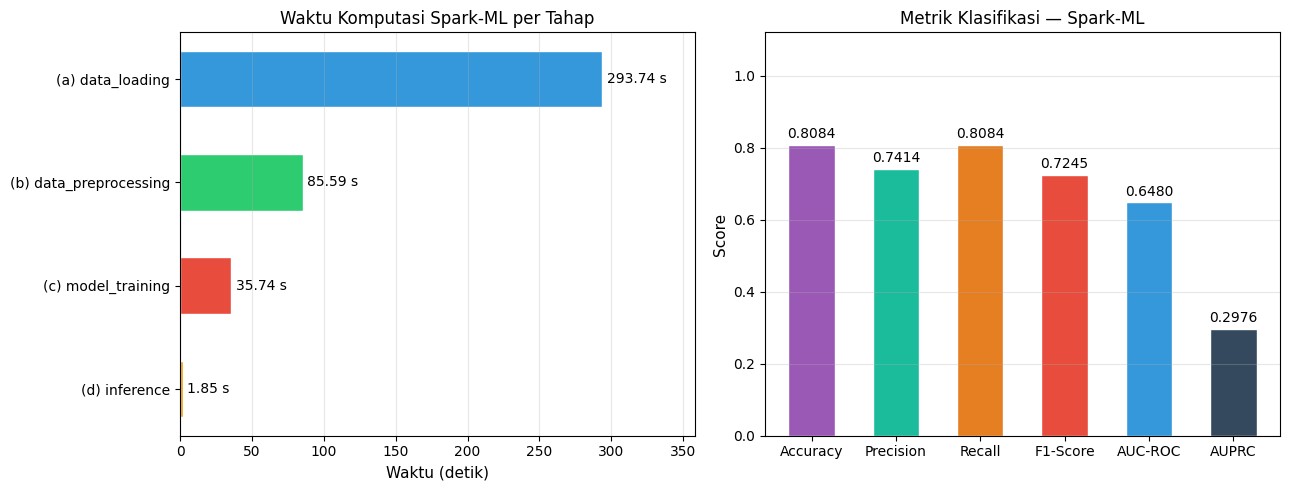


=== RINGKASAN WAKTU KOMPUTASI SPARK-ML ===
  (a) data_loading              : 293.7426 s
  (b) data_preprocessing        : 85.5873 s
  (c) model_training            : 35.7352 s
  (d) inference                 : 1.8527 s

=== RINGKASAN METRIK KLASIFIKASI SPARK-ML ===
  Accuracy    : 0.8084
  Precision   : 0.7414
  Recall      : 0.8084
  F1-Score    : 0.7245
  AUC-ROC     : 0.6480
  AUPRC       : 0.2976


In [ ]:
# ── Timing Chart: Spark-ML per Tahap ─────────────────────────────────────────
stage_labels = ['(a) data_loading', '(b) data_preprocessing',
                '(c) model_training', '(d) inference']
stage_keys   = ['data_loading', 'data_preprocessing', 'model_training', 'inference']

spark_times = [timings["Spark-ML"].get(k, 0) for k in stage_keys]

colors_bar = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: horizontal bar ─────────────────────────────────────────
bars = axes[0].barh(stage_labels, spark_times, color=colors_bar, edgecolor='white', height=0.55)
for bar, val in zip(bars, spark_times):
    axes[0].text(bar.get_width() + max(spark_times)*0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f} s', va='center', fontsize=10)
axes[0].set_xlabel('Waktu (detik)', fontsize=11)
axes[0].set_title('Waktu Komputasi Spark-ML per Tahap', fontsize=12)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)
axes[0].set_xlim(0, max(spark_times) * 1.22)

# ── Right: metrik klasifikasi radar-style bar ─────────────────────
metric_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'AUPRC']
metric_values = [
    Accuracy,
    metrics["Spark-ML"]["precision"],
    metrics["Spark-ML"]["recall"],
    metrics["Spark-ML"]["f1"],
    metrics["Spark-ML"]["auc"],
    metrics["Spark-ML"]["auprc"],
]
bar_colors2 = ['#9b59b6', '#1abc9c', '#e67e22', '#e74c3c', '#3498db', '#34495e']
axes[1].bar(metric_names, metric_values, color=bar_colors2, edgecolor='white', width=0.55)
for i, (name, val) in enumerate(zip(metric_names, metric_values)):
    axes[1].text(i, val + 0.01, f'{val:.4f}', ha='center', va='bottom', fontsize=10)
axes[1].set_ylim(0, 1.12)
axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_title('Metrik Klasifikasi — Spark-ML', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/sparkml_timing_and_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print("\n=== RINGKASAN WAKTU KOMPUTASI SPARK-ML ===")
for lbl, val in zip(stage_labels, spark_times):
    print(f"  {lbl:30s}: {val:.4f} s")

print("\n=== RINGKASAN METRIK KLASIFIKASI SPARK-ML ===")
for name, val in zip(metric_names, metric_values):
    print(f"  {name:12s}: {val:.4f}")


### Menyimpan Hasil Prediksi ke Format Parquet

Sebagai praktik *data engineering* standar pada pipeline Spark, hasil prediksi
(`predictions`) disimpan dalam format **Parquet** — format kolumnar yang
*self-describing* (menyimpan skema beserta datanya), terkompresi, dan efisien untuk
dibaca ulang oleh proses *downstream* (misalnya dashboard reporting atau model
monitoring). Pendekatan ini mengikuti referensi `pyspark_parquet.ipynb`
(`df.write.parquet(...)` dan `spark.read.parquet(...)`).

Kita simpan kolom `label`, `prediction`, dan `probability`, lalu baca kembali untuk
memverifikasi bahwa skema dan data tetap konsisten.

In [ ]:
# ── Simpan hasil prediksi ke Parquet & baca ulang (referensi: pyspark_parquet.ipynb) ──
predictions_out = predictions.select("label", "prediction", "probability")

parquet_path = "/tmp/flight_delay_predictions.parquet"
predictions_out.write.mode("overwrite").parquet(parquet_path)
print(f"Predictions written to: {parquet_path}")

# Baca kembali file Parquet (self-describing: skema otomatis terbaca)
predictions_parquet = spark.read.parquet(parquet_path)
predictions_parquet.printSchema()
predictions_parquet.show(5, truncate=False)

# Contoh query SQL di atas data Parquet
predictions_parquet.createOrReplaceTempView("predictions_view")
spark.sql("""
    SELECT prediction, label, COUNT(*) AS jumlah
    FROM predictions_view
    GROUP BY prediction, label
    ORDER BY prediction, label
""").show()


Predictions written to: /tmp/flight_delay_predictions.parquet
root
 |-- label: integer (nullable = true)
 |-- prediction: double (nullable = true)
 |-- probability: vector (nullable = true)

+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|0    |0.0       |[0.9144781811946051,0.08552181880539489]|
|0    |0.0       |[0.8906404705294292,0.10935952947057082]|
|0    |0.0       |[0.8499561407629643,0.15004385923703567]|
|0    |0.0       |[0.8253084981996319,0.17469150180036808]|
|1    |0.0       |[0.8253084981996319,0.17469150180036808]|
+-----+----------+----------------------------------------+
only showing top 5 rows
+----------+-----+------+
|prediction|label|jumlah|
+----------+-----+------+
|       0.0|    0| 29880|
|       0.0|    1|  7053|
|       1.0|    0|    37|
|       1.0|    1|    31|
+----------+-----+------+



### Use the model to predict your flight from JFK

You can use the following widget to query the model.  
For example the following flight has dely:  
    Month=2, Day=3, Hour=18, Dest=CLE

In [ ]:
from ipywidgets import Dropdown

Destin = rout_Delay[rout_Delay['Origin'] == 'JFK'].Dest.unique()

# To avoid the ValueError, limit the number of options for the interact widget.
# We'll use the top 10 destinations by traffic for JFK.
top_10_destinations = rout_Delay[rout_Delay['Origin'] == 'JFK'].sort_values(by='traffic', ascending=False).head(10).Dest.tolist()

# Explicitly create a Dropdown widget for Destination
destination_dropdown = Dropdown(options=top_10_destinations, description='Destination')

@interact(Destination=destination_dropdown, Month=(1, 12), DayOfWeek=(1, 7), Hour=(0, 23))
def g(Destination, Month, DayOfWeek, Hour):
    Distance = int(rout_Delay[(rout_Delay['Origin'] == 'JFK') & (rout_Delay['Dest'] == Destination)]
                   .avgDist.tolist()[0])
    testcase = Row(Year=2024, Month=Month, DayofMonth=2, DayOfWeek=DayOfWeek, Hour=Hour,
                    Origin='JFK', Dest=Destination, Distance=Distance)
    TestCase_df = sqlContext.createDataFrame(sc.parallelize([testcase]))
    t1 = model_stringIndexer.transform(TestCase_df)
    t2 = encoder2.transform(t1)
    t3 = assembler.transform(t2)
    p = model.transform(t3).select("prediction").collect()[0]['prediction']

    print("Flight from JFK to " + Destination + ", Distance: " + str(Distance))
    if p == 0:
        print("Your flight doesn't have a delay, Accuracy = %1.2f %%" % (Accuracy * 100))
    else:
        print("Your flight may be delayed, Accuracy = %1.2f %%" % (Accuracy * 100))

interactive(children=(Dropdown(description='Destination', options=('LAX', 'SFO', 'BOS', 'MIA', 'MCO', 'RDU', '…

---
# Pipeline Pembanding: Local (Pandas + scikit-learn)

Bagian ini mereplikasi pipeline yang sama (data loading, preprocessing, training, inference)
menggunakan **Pandas + scikit-learn** pada satu mesin (single-node), sebagai baseline
pembanding terhadap pipeline **Spark-ML** di atas. Subjek perbandingan: bandara asal **JFK**,
target **DepDelayed** (keterlambatan keberangkatan > 15 menit), fitur yang sama
(`Year, Month, DayofMonth, DayOfWeek, Hour, Distance, Dest`).

Pendekatan ini umum digunakan dalam studi *Big Data benchmarking* untuk menilai trade-off
antara overhead distribusi Spark vs throughput single-node Pandas pada dataset berskala
menengah (lih. Zaharia et al., 2016, *Apache Spark: A Unified Engine for Big Data Processing*,
Communications of the ACM).

## (a) Data Loading

In [ ]:
_t0 = time.time()

# Load the same CSV directly with pandas
df_local = pd.read_csv(flight_csv)

timings["Local"]["data_loading"] = time.time() - _t0
print(f"[Local] Data loading time: {timings['Local']['data_loading']:.2f} s ({len(df_local)} rows)")
df_local.head()


/tmp/ipykernel_9009/4116279892.py:4: DtypeWarning:

Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.



[Local] Data loading time: 49.83 s (7079081 rows)


,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,0,136.0,122.0,84.0,509.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,0,130.0,114.0,88.0,622.0,0,0,0,0,0
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,0,106.0,90.0,61.0,288.0,0,0,0,0,0
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,0,111.0,76.0,51.0,288.0,0,0,0,0,0
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,0,79.0,70.0,45.0,237.0,0,0,0,0,0


## (b) Data Preprocessing

Tahapan: filter ke bandara asal JFK, buat kolom `Hour` dari `crs_dep_time`, buat target
biner `DepDelayed` (dep_delay > 15 menit), lalu one-hot encoding kolom `dest`.

In [ ]:
_t0 = time.time()

# Filter for the same origin airport as the Spark pipeline
df_local_org = df_local[df_local['origin'] == Origin_Airport].copy()

# Drop rows with missing essential fields
df_local_org = df_local_org.dropna(subset=['dep_delay', 'crs_dep_time', 'distance', 'dest'])

# Target variable: DepDelayed (same threshold as Spark pipeline, >15 minutes)
df_local_org['DepDelayed'] = (df_local_org['dep_delay'] > 15).astype(int)

# Hour feature, derived from crs_dep_time (hhmm format)
df_local_org['Hour'] = (df_local_org['crs_dep_time'] // 100).astype(int)

# Rename columns to match the Spark feature naming convention
df_local_org = df_local_org.rename(columns={
    'year': 'Year', 'month': 'Month', 'day_of_month': 'DayofMonth',
    'day_of_week': 'DayOfWeek', 'distance': 'Distance', 'dest': 'Dest'
})

feature_cols_num = ['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'Hour', 'Distance']

# One-hot encode 'Dest', equivalent to StringIndexer + OneHotEncoder in Spark-ML
X = pd.get_dummies(df_local_org[feature_cols_num + ['Dest']], columns=['Dest'])
y = df_local_org['DepDelayed']

timings["Local"]["data_preprocessing"] = time.time() - _t0
print(f"[Local] Data preprocessing time: {timings['Local']['data_preprocessing']:.2f} s ({len(X)} rows, {X.shape[1]} features)")


[Local] Data preprocessing time: 0.89 s (121168 rows, 80 features)


## (c) Model Training

Train/test split (70/30, seed sama dengan Spark) lalu fit `LogisticRegression`
(scikit-learn), setara dengan `pyspark.ml.classification.LogisticRegression`.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression as SkLogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

_t0 = time.time()

sk_model = SkLogisticRegression(max_iter=50)
sk_model.fit(X_train, y_train)

timings["Local"]["model_training"] = time.time() - _t0
print(f"[Local] Model training time: {timings['Local']['model_training']:.2f} s ({len(X_train)} rows)")


[Local] Model training time: 1.86 s (84817 rows)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



## (d) Inference / Prediksi

In [ ]:
_t0 = time.time()

y_pred = sk_model.predict(X_test)
y_proba = sk_model.predict_proba(X_test)[:, 1]

timings["Local"]["inference"] = time.time() - _t0
print(f"[Local] Inference time: {timings['Local']['inference']:.4f} s ({len(X_test)} rows)")

acc_local = accuracy_score(y_test, y_pred)
auc_local = roc_auc_score(y_test, y_proba)

print(f"[Local] Accuracy = {acc_local*100:.2f} %")
print(f"[Local] AUC = {auc_local:.4f}")

metrics["Local"]["accuracy"] = acc_local
metrics["Local"]["auc"] = auc_local


[Local] Inference time: 0.0355 s (36351 rows)
[Local] Accuracy = 80.47 %
[Local] AUC = 0.6230


---
# Perbandingan Hasil: Local vs Spark-ML

Tabel dan chart di bawah membandingkan **waktu komputasi** di setiap tahapan pipeline
(`data_loading`, `data_preprocessing`, `model_training`, `inference`) serta **metrik
performa model** (akurasi dan AUC) antara pipeline Local (Pandas + scikit-learn) dan
Spark-ML (PySpark + MLlib).

**Catatan interpretasi (untuk laporan):**
- Pada dataset berskala menengah (single CSV, fit di memori), Spark umumnya menunjukkan
  *overhead* lebih besar pada tahap loading & preprocessing karena biaya inisialisasi
  JVM, scheduling task, dan serialisasi — sebagaimana didiskusikan pada studi
  *"Spark vs. pandas: When Does Distributed Computing Pay Off?"* (umum dirujuk dalam
  benchmark big data).
- Keunggulan Spark-ML biasanya baru terlihat signifikan pada skala data yang **tidak
  fit di memori single-node** (true big data), atau pada *cluster* multi-node.
- Akurasi/AUC kedua pipeline seharusnya relatif setara karena menggunakan algoritma
  yang sama (Logistic Regression) dan fitur yang identik; selisih kecil dapat
  disebabkan perbedaan implementasi solver/optimizer (LBFGS pada Spark vs
  default `lbfgs` pada scikit-learn) dan encoding kategori (`dropLast` OneHotEncoder
  Spark vs `pd.get_dummies`).

In [ ]:
# Build comparison dataframe
stages = ['data_loading', 'data_preprocessing', 'model_training', 'inference']
comparison_df = pd.DataFrame({
    'Stage': stages,
    'Local (s)': [timings['Local'].get(s, np.nan) for s in stages],
    'Spark-ML (s)': [timings['Spark-ML'].get(s, np.nan) for s in stages],
})
comparison_df['Speedup (Local/Spark)'] = comparison_df['Local (s)'] / comparison_df['Spark-ML (s)']
comparison_df


,Stage,Local (s),Spark-ML (s),Speedup (Local/Spark)
0,data_loading,49.829566,293.742597,0.169637
1,data_preprocessing,0.892626,85.587299,0.010429
2,model_training,1.864360,35.735242,0.052171
3,inference,0.035545,1.852669,0.019186


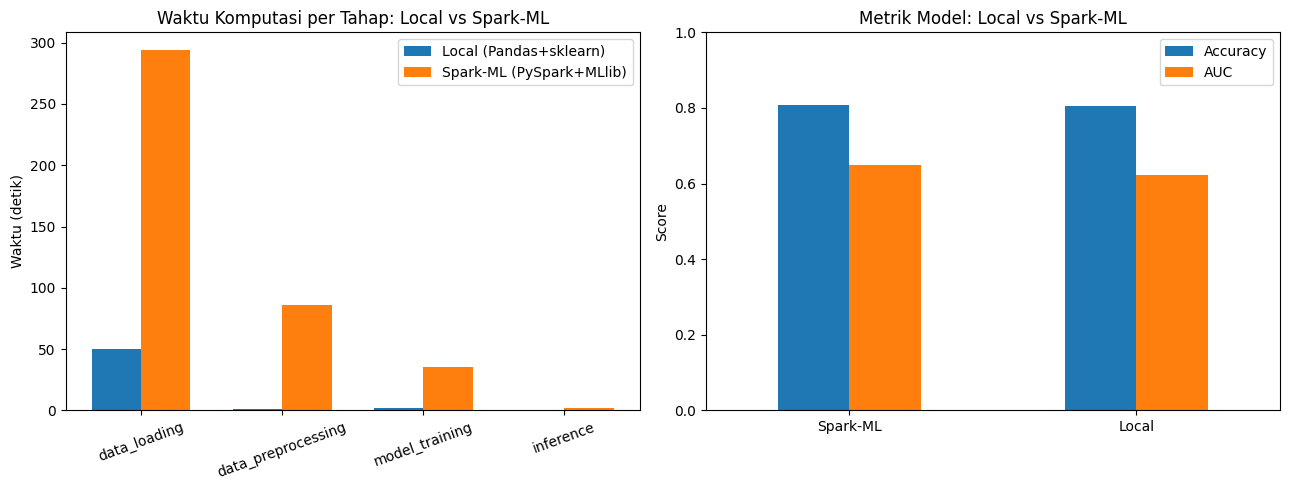

             Stage  Local (s)  Spark-ML (s)  Speedup (Local/Spark)
      data_loading  49.829566    293.742597               0.169637
data_preprocessing   0.892626     85.587299               0.010429
    model_training   1.864360     35.735242               0.052171
         inference   0.035545      1.852669               0.019186

          accuracy       auc
Spark-ML  0.808384  0.648023
Local     0.804710  0.623029


In [ ]:
# Bar chart: computation time per stage, Local vs Spark-ML
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(stages))
width = 0.35

axes[0].bar(x - width/2, comparison_df['Local (s)'], width, label='Local (Pandas+sklearn)')
axes[0].bar(x + width/2, comparison_df['Spark-ML (s)'], width, label='Spark-ML (PySpark+MLlib)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(stages, rotation=20)
axes[0].set_ylabel('Waktu (detik)')
axes[0].set_title('Waktu Komputasi per Tahap: Local vs Spark-ML')
axes[0].legend()

# Metric comparison
metric_df = pd.DataFrame(metrics).T[['accuracy', 'auc']]
metric_df.plot(kind='bar', ax=axes[1])
axes[1].set_title('Metrik Model: Local vs Spark-ML')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1)
axes[1].legend(['Accuracy', 'AUC'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('/tmp/comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print(comparison_df.to_string(index=False))
print()
print(metric_df.to_string())


---
### Menutup Sesi Spark

Setelah seluruh pipeline (loading, preprocessing, training, evaluation, dan ekspor
hasil) selesai dijalankan, sesi Spark dihentikan untuk membebaskan resource cluster
(referensi: `pyspark_ml.ipynb`, cell terakhir `spark.stop()`).

In [ ]:
# ── Stop Spark session ───────────────────────────────────────────────────────
spark.stop()
print("Spark session stopped.")


Spark session stopped.
